In [3]:
# 1. CONNECT TO MONGODB
import sys
sys.path.append('../src')

import pymongo
import pandas as pd
from load_to_mongodb import db

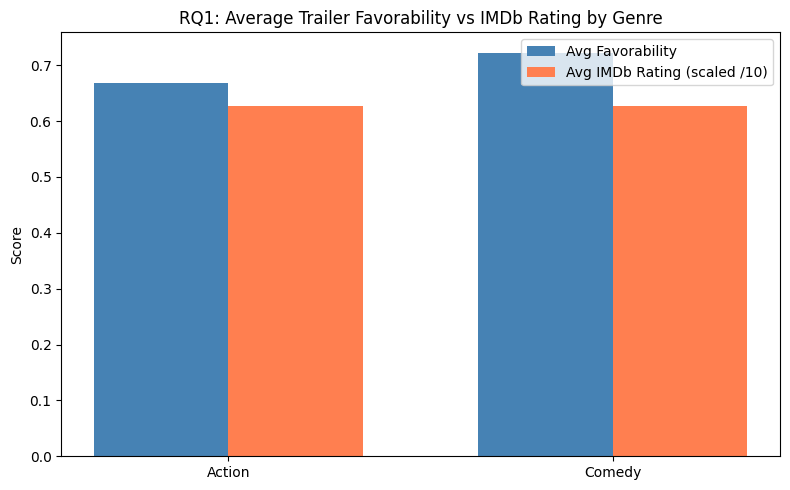

RQ1 plot saved.


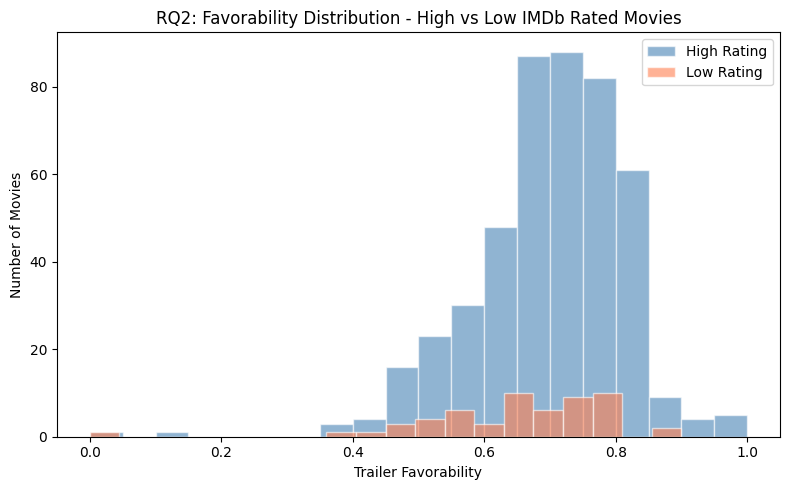

RQ2 plot saved.


/var/folders/vg/jq4dk0x51l3_xhcyvpt98ttw0000gn/T/ipykernel_36305/1750532435.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q3_df, x='rating_group', y='favorability',


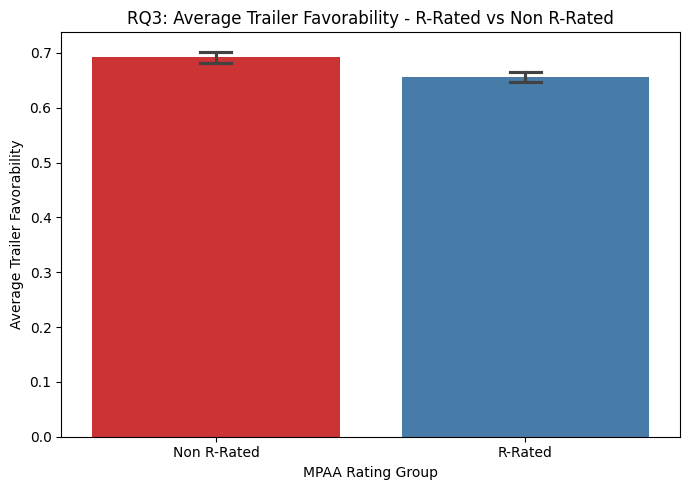

RQ3 plot saved.


In [ ]:
# =====================================================
# CPSC 368 Phase 4: MongoDB Visualizations
#
# External Libraries:
#   - pandas: data manipulation and DataFrame creation
#   - matplotlib: base plotting library
#   - seaborn: statistical data visualization
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("results", exist_ok=True)

# =====================================================
# VISUALIZATIONS
# Note: Phase 3 used scatter plots with trend lines (Q1, Q2)
# and box plots (Q3). Phase 4 uses different chart types
# to provide new perspectives on the same data.
# =====================================================

# --- Visualization 1: Genre Analysis ---
# Grouped bar chart of average favorability and average IMDb
# rating per genre. Phase 3 used scatter plots with trend lines.
q1_summary = q1_df.groupby('genre').agg(
    avg_favorability=('favorability', 'mean'),
    avg_imdb=('averageRating', 'mean')
).reset_index()

x = range(len(q1_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - width/2 for i in x], q1_summary['avg_favorability'],
       width, label='Avg Favorability', color='steelblue')
ax.bar([i + width/2 for i in x], q1_summary['avg_imdb'] / 10,
       width, label='Avg IMDb Rating (scaled /10)', color='coral')
ax.set_xticks(list(x))
ax.set_xticklabels(q1_summary['genre'])
ax.set_ylabel("Score")
ax.set_title("RQ1: Average Trailer Favorability vs IMDb Rating by Genre")
ax.legend()
plt.tight_layout()
plt.savefig("results/mongodb_rq1_bar.png", dpi=150)
plt.show()
print("RQ1 plot saved.")

# --- Visualization 2: High vs Low Rated Movies ---
# Overlapping histogram showing favorability distribution
# for high vs low rated movies. Phase 3 used scatter plots.
fig, ax = plt.subplots(figsize=(8, 5))
for group, color in [("high rating", "steelblue"), ("low rating", "coral")]:
    subset = q2_df[q2_df['rating_group'] == group]['favorability']
    ax.hist(subset, bins=20, alpha=0.6, label=group.title(),
            color=color, edgecolor='white')
ax.set_xlabel("Trailer Favorability")
ax.set_ylabel("Number of Movies")
ax.set_title("RQ2: Favorability Distribution - High vs Low IMDb Rated Movies")
ax.legend()
plt.tight_layout()
plt.savefig("results/mongodb_rq2_histogram.png", dpi=150)
plt.show()
print("RQ2 plot saved.")

# --- Visualization 3: R-Rated vs Non R-Rated ---
# Bar chart comparing average favorability between
# R-Rated and Non R-Rated movies. Phase 3 used box plots.
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=q3_df, x='rating_group', y='favorability',
            palette='Set1', capsize=0.1, ax=ax)
ax.set_xlabel("MPAA Rating Group")
ax.set_ylabel("Average Trailer Favorability")
ax.set_title("RQ3: Average Trailer Favorability - R-Rated vs Non R-Rated")
plt.tight_layout()
plt.savefig("results/mongodb_rq3_bar.png", dpi=150)
plt.show()
print("RQ3 plot saved.")

RQ1: Average Trailer Favorability vs IMDb Rating by Genre
The average IMDb ratings for Action and Comedy movies are very close, both being ~0.63 on a scale, or ~6.3/10. The average trailer favorability for Comedy movies are slightly higher, ~0.72, compared to Action movies, ~0.67, implying that Comedy trailers are slightly better received on YouTube.

RQ2: Favorability Distribution: High vs Low IMDb Rated Movies
The number of High-rated movies is significantly higher, and their favorability is concentrated between 0.6 and 0.8, with a peak between 0.65 and 0.70. The number of low-rated movies is significantly lower, and their favorability is distributed almost evenly between 0.4 and 0.9. This indicates that High IMDb-rated movies have highly positive trailers, whereas low IMDb-rated movies have variable trailer favorability, with some movies having highly positive trailers regardless of their low IMDb ratings.

RQ3: Average Trailer Favorability: R-Rated vs Non R-Rated The average favorability of R-Rated trailers (~0.69) is slightly higher compared to Non R-Rated trailers (~0.66). The error bars do not overlap extensively. This may imply that R-Rated trailers are slightly more popular compared to Non R-Rated trailers on YouTube. This could happen because R-Rated movies have a more attentive adult audience compared to other genres. 

Overall Consistency with Phase 3: The results obtained are consistent with the findings of Phase 3. 